# GO Analysis

**Author:** Erik Am&eacute;zquita

**Date:** March 2026

Now that you have identified a few interesting parameter combinations, it is time to check if the clusters made by mapper are biologically significant. 

## On the usage of this Notebook

You don't need to know how to code to use this notebook. If you've managed to get a open this very notebook with Jupyter, you've already done the hardest part. You will only need to change an HTML filename and a layout option

- You need to click run for *all* cells.
- You only need to run Parts I thru II *once* (running them again won't do anything bad but will take longer).
- **You will need to edit the code for Part III**
- After your edits, you just need to run the rest of the Notebook

---

# Part I: Imports

We start importing some standard libraries and sublibraries for non-TDA stuff. 

For the GO analysis-specific computations, we'll use `goatools`.

In [1]:
import os
import glob
import copy
import re
import json
import itertools
from importlib import reload

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import networkx as nx
import utils

import matplotlib as mpl

from statsmodels.stats.multitest import multipletests
from goatools.obo_parser import GODag
from goatools.anno.idtogos_reader import IdToGosReader
from goatools.go_enrichment import GOEnrichmentStudy

---

# Part II: Load and transform the reads

- Define some constant variables
- Repeat the transformation of reads to log-foldchange scores as in the Notebook 01

In [2]:
# Column headers for the GO analysis file
hdrs = ["Namespace", "GO ID", "Enriched/Purified", "GO Terms", "pval_uncorr", 
        "Benjamimi/Hochberg", "Bonferroni", "Study Ratio", "Population Ratio"]

# Row values pattern to save the final GO analysis file
pat = "{NS},{GO},{e},{GOTERM},{PVAL:8.2e},\
       {BH:8.2e},{BONF:8.2e},{RS:>12},{RP:>12}\n"

# Plot values for the final GO analysis cluster localization
colors = ['yellow', 'lightgray', 'lime', 'cyan', 'peachpuff', 'thistle', 'pink']
markers = ['o', 's', 'D']

fig, ax = plt.subplots()
for j in range(len(colors) * len(markers)):
    ax.scatter([0],[0], marker=markers[j%3], color=colors[j%7], ec='k', lw=1, label='{:02}'.format(j+1))
handles, labels = ax.get_legend_handles_labels()
plt.close()

In [3]:
fs = 12
min_tpm = 100
nlabels = ['min', 'mean', 'max', 'median', 'std', 'size', 'sqrtsize', 'cbrtsize']
plot_kw = dict(format='png', bbox_inches='tight', dpi=150)

src = os.pardir + os.sep + 'raw' + os.sep
dst = os.pardir + os.sep + 'outputs' + os.sep
pdst = os.pardir + os.sep + 'plots' + os.sep
p = re.compile('(.*)_B(.*)_Ov(.*)_dbscan(.*)')

tpm = pd.read_csv(src + 'TPM_combined.csv', index_col=0)
deseq2 = pd.read_csv(src + 'DESeq2_combined.csv', index_col=0)
filters = pd.read_csv(src + 'Combined_gene_filters.csv', index_col=0)
population_ids = set(tpm.index)
lenses = ['LFC New', 'LFC Attack']

- Necessary setup for GO analysis with `goatools`
- Only needs to be run once

**Make sure you have dowloaded the files `go-basic.obo` and `os_loci_go_association.txt` and `clean_oryza_go_terms.csv`**

**Make sure these files are placed in the `raw` folder (the same place where you have the reads data)**

In [4]:
# Populate necessary variables to run GO Enrichment
godag = GODag(src + "go-basic.obo")
assoc_file = src + "os_loci_go_association.txt"

annoobj = IdToGosReader(assoc_file, godag=godag)
id2gos = annoobj.get_id2gos()

# GO Enrichment
goeaobj = GOEnrichmentStudy(
    population_ids,
    annoobj.get_id2gos(),
    godag,
    methods=['bonferroni', 'fdr_bh'],
    pvalcalc='fisher_scipy_stats')

dfterms = pd.read_csv(src + 'clean_oryza_go_terms.csv')

../raw/go-basic.obo: fmt(1.2) rel(2026-01-23) 42,036 Terms
HMS:0:00:00.298669 127,495 annotations READ: ../raw/os_loci_go_association.txt 
25463 IDs in loaded association branch, biological_process
25463 IDs in loaded association branch, biological_process

Load  Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 86% 16,885 of 19,729 population items found in association


---

# Part III: Load the mapper graph

You've already computed and saved the mapper graphs as HTML files in the Notebook 01. Now we simply load those HTMLs for further analysis.

### &#10024; Change the `filename` accordingly.

### &#10024; Change the layout variable `poskey`

In [5]:
# Replace the filename 
filename = dst + 'TPM_MeanCorr_B70_Ov50_dbscan0,6'
if len(os.path.splitext(filename)[1]) == 0:
    filename += '.html'
poskey = 'spectral'
 
# You don't need to change anything else
# Figure out Mapper parameters based on the filename
bname = os.path.splitext(os.path.split(filename)[1])[0]
filternames, binno, overlap, dbscan = p.findall(bname)[0]
filternames = filternames.replace('_',' ').replace('+',' & ')
dbscan = dbscan.replace(',','.')
overlap += '%'
print(filternames, binno, overlap, dbscan, sep='\t')
mtitle = f'Filters: {filternames}, Bins#: {binno}, Overlap: {overlap}, DBSCAN($\\varepsilon$): {dbscan}'
fname = pdst + bname
print(mtitle)

dfpos = pd.read_csv(os.pardir + os.sep + 'positions' + os.sep + bname + '.csv', index_col=0)
pos = dict(zip(dfpos.index, dfpos[[poskey+'_x', poskey+'_y']].to_numpy()))
ffname = fname+'_'+poskey.replace(' ', '_')

ddst = dst + bname + os.sep
if not os.path.isdir(dst + bname):
    os.mkdir(ddst)

TPM MeanCorr	70	50%	0.6
Filters: TPM MeanCorr, Bins#: 70, Overlap: 50%, DBSCAN($\varepsilon$): 0.6


In [6]:
# Load the actual Mapper info
with open(filename, encoding="utf-8") as f:
    jdict = utils.html2json(f.read())
graph = utils.json2mapperG(jdict)

# Compute some basic metrics for each node
columns  = list(itertools.chain(*[ [f'{lenses[i]} {ll}' for ll in nlabels[:5] ] for i in range(len(lenses)) ]))
columns += list(itertools.chain(*[ [f'{lenses[i]} abs {ll}' for ll in nlabels[:5] ] for i in range(len(lenses)) ]))
columns += nlabels[5:]
metanode = pd.DataFrame(np.nan, index=graph['nodes'].keys(), columns=columns)
for key in metanode.index:
    metanode.loc[key, 'size'] = len(graph['nodes'][key])
    for ls in lenses:
        nn = filters[ls].iloc[ graph['nodes'][key] ]
        for attr in nlabels[:5]:
            metanode.loc[key, ls + ' ' + attr] = getattr( np, attr)(nn)
        nn = nn.abs()
        for attr in nlabels[:5]:
            metanode.loc[key, ls + ' abs ' + attr] = getattr( np, attr)(nn)

# Make a networkx G with the mapper data
G = utils.mapper2networkx(graph)
nG = list(G.nodes)
n2g = dict(zip(nG, range(1,1+len(nG))))
drawkw = dict(G=G, node_size=0, width = 1, edge_color='gray',
              with_labels=False, hide_ticks=True, font_size=6)

---

# Part IV: Getting the "intersting" nodes of the mapper graph

We'll say that a node is *interesting* if it contains mostly genes that are differentially expressed for one comparison. Remember that high log fold-change values indicate that a gene is differentially expressed.

The best case scenario would be to find that different comparisons highlight different strands of the graph. But alas, that's not always the case. We can still do GO Analysis and see what we get.

- For each node we check log-foldchange values for all the genes inside of it.
- Then we take the median
- Take the 90th quantile&mdash;consider only the nodes that land on the Top 10%

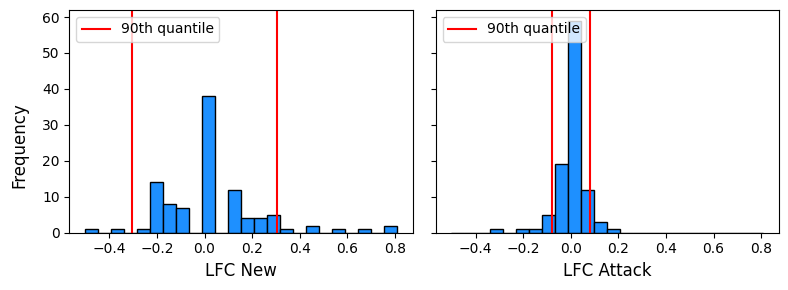

In [7]:
medians = metanode[ [lenses[i] + ' mean' for i in range(len(lenses))] ]
thr = np.quantile(medians.abs(), .9, axis=0)
bins = np.linspace(medians.min().min(), medians.max().max(), 25)

fig, ax = plt.subplots(1, len(thr), figsize=(4*len(thr), 3), sharex=True, sharey=True)
for i in range(len(ax)):
    ax[i].hist(medians.iloc[:,i], bins=bins, edgecolor='k', color='dodgerblue')
    ax[i].axvline(thr[i], c='r', label='90th quantile')
    ax[i].axvline(-thr[i], c='r')
    ax[i].legend(loc='upper left')
    ax[i].set_xlabel(lenses[i], fontsize=fs)
fig.supylabel('Frequency', fontsize=fs);
fig.tight_layout()

- Only highlight the interesting nodes

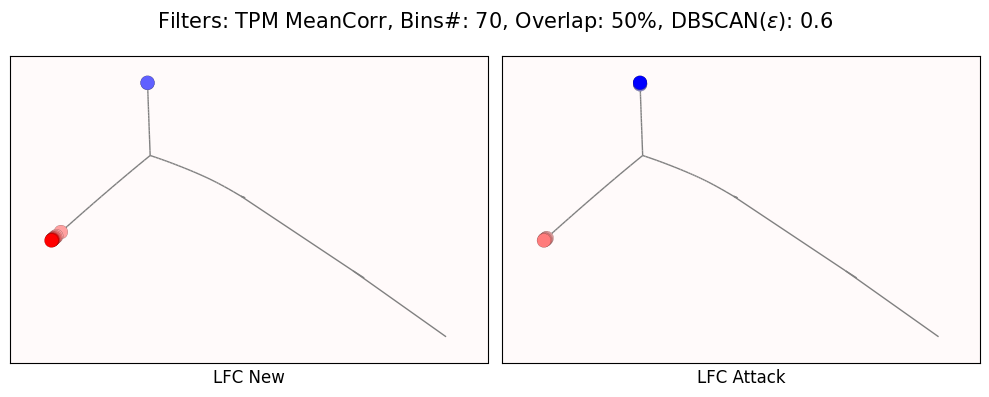

In [8]:
fig, ax = plt.subplots(1, len(lenses), figsize=(5*len(lenses), 4), sharex=True, sharey=True)
for i in range(len(lenses)):
    
    topvals = medians.iloc[:,i].abs() > thr[i]
    topvals = medians.iloc[:,i][topvals]
    vmax = topvals.abs().max()
    
    ax[i].set_facecolor('snow')
    nx.draw_networkx(pos=pos, ax=ax[i], **drawkw )
    
    bar = dfpos.loc[topvals.index, [poskey + '_x', poskey + '_y']].T.to_numpy()
    ax[i].scatter(*bar, c=topvals, cmap='bwr', vmin=-vmax, vmax=vmax, ec='k', lw=0.1, s=100)
    ax[i].set_xlabel(lenses[i], fontsize=fs)

fig.suptitle(mtitle, fontsize=1.25*fs)
fig.tight_layout();

---

# Part V: GO Analysis on intersting clusters

An "interesting" cluster is a bunch of interesting nodes that at least share an edge together. Sometimes, an interesting cluster will be a single interesting node itself.

For each cluster, we look at all the genes comprised in all the cluster nodes. We then perform GO analysis on these genes to check if the cluster is biologically meaningful.

In [79]:
clusters = dict()

for k in range(len(lenses)):
    print('LOOKING AT COMPARSION:\t', lenses[k])
    clusters[lenses[k]] = dict()
    topvals = medians.iloc[:,k].abs() > thr[k]
    topvals = medians.iloc[:,k][topvals]
    
    
    H = G.subgraph(topvals.index)
    S = [H.subgraph(c).copy() for c in sorted(nx.connected_components(H), key=len, reverse=True)]
    gene_groups = [set() for _ in range(len(S)) ]
    
    print('Found subgraphs:\t', len(S))
    
    for i in range(len(S)):
        
        for node in S[i]:
            foo = tpm.iloc[graph['nodes'][node]].index.values
            gene_groups[i] |= set(foo)
        print('Subgraph:', i+1, 'has', len(S[i]), 'nodes and', len(gene_groups[i]),'different genes.')
        print('--- ', [ n2g[n] for n in S[i] ])
        results = goeaobj.run_study_nts(gene_groups[i])
        anysignif = (np.array([ r.p_fdr_bh for r in results ]) <= 0.05).any()
        
        if anysignif:
            clusters[lenses[k]][i+1] = list(S[i])
            
            # Collect GO Enrichment results, format and write to csv file.
            goea_out = ddst + '{:02d}_'.format(k) + lenses[k].replace(' ','_') + '_-_gotest_{:02d}.csv'.format(i+1)
            
            # Write to file, one row at a time: iff adjusted p-value < 0.05
            with open(goea_out, "w") as fp:
                fp.write(",".join(hdrs) + "\n")
                for ntd in sorted(results, key=lambda nt: [nt.p_uncorrected, nt.GO]):
                    if ntd.p_fdr_bh <= 0.05:
                        ogs = dfterms[dfterms["GO ID"] == ntd.GO]["Locus"].tolist()
                        fp.write(pat.format(
                                NS=ntd.NS,  GO=ntd.GO,  e=ntd.enrichment,  GOTERM=ntd.goterm.name,
                                RS='{}/{}'.format(*ntd.ratio_in_study), RP='{}/{}'.format(*ntd.ratio_in_pop),
                                PVAL=ntd.p_uncorrected, BONF=ntd.p_bonferroni, BH=ntd.p_fdr_bh))
            
            print(f"Wrote results to {goea_out}\n**")
    print('\n********************************************************\n')

LOOKING AT COMPARSION:	 LFC New
Found subgraphs:	 3
Subgraph: 1 has 8 nodes and 1419 different genes.
---  [91, 89, 99, 96, 87, 97, 101, 94]

Runing  Ontology Analysis: current study set of 1419 IDs.
 68%    971 of  1,419 study items found in association
100%  1,419 of  1,419 study items found in population(19729)
Calculating 149 uncorrected p-values using fisher_scipy_stats
     149 terms are associated with 16,885 of 19,729 population items
     141 terms are associated with    971 of  1,419 study items
  METHOD bonferroni:
      26 GO terms found significant (< 0.05=alpha) (  4 enriched +  22 purified): local bonferroni
     324 study items associated with significant GO IDs (enriched)
     971 study items associated with significant GO IDs (purified)
  METHOD fdr_bh:
      36 GO terms found significant (< 0.05=alpha) (  6 enriched +  30 purified): statsmodels fdr_bh
     336 study items associated with significant GO IDs (enriched)
     971 study items associated with significant G

### Save the results

- Keep a JSON file with the record of which comparisons have which intersting clusters (and the nodes making up such clusters)
- Make a plot highlighting these interesting clusters

In [63]:
datafile = ddst + 'significant_clusters_-_gotest.json'
with open(datafile, 'w') as f:
    json.dump(clusters, f, indent=1, separators=(',', ':'))

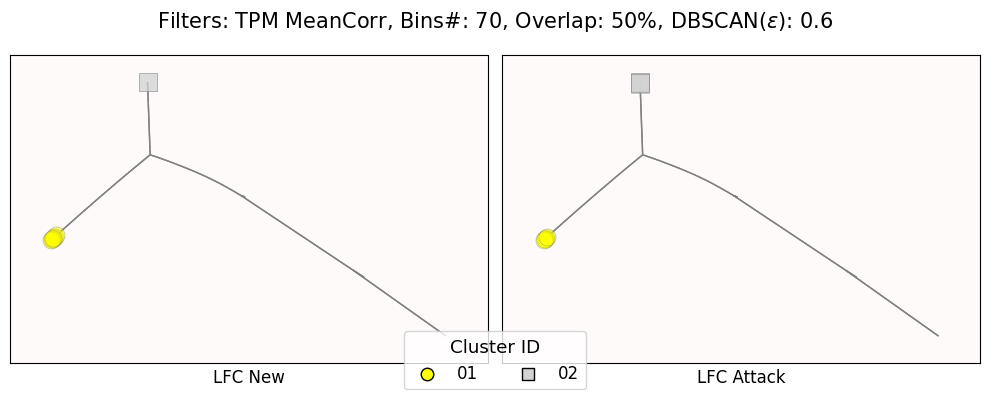

In [81]:
maxlen = max([len(clusters[key]) for key in clusters])

fig, ax = plt.subplots(1, len(lenses), figsize=(5*len(lenses), 4), sharex=True, sharey=True)
for i in range(len(lenses)):
    
    topvals = medians.iloc[:,i].abs() > thr[i]
    topvals = medians.iloc[:,i][topvals].index
    
    ax[i].set_facecolor('snow')
    nx.draw_networkx(pos=pos, ax=ax[i], **drawkw )

    ax[i].set_xlabel(lenses[i], fontsize=fs)
    nx.draw_networkx(pos=pos, ax=ax[i], **drawkw )
    
    for j in clusters[lenses[i]]:
        nS = clusters[lenses[i]][j]
        bar = dfpos.loc[ nS, [poskey + '_x', poskey + '_y']].T.to_numpy()
        ax[i].scatter(*bar, color=colors[(j-1)%7], marker=markers[(j-1)%3], s=150, ec='gray', lw=0.5, zorder=4, alpha=0.5)
        
fig.legend(handles[:maxlen], labels[:maxlen], loc='lower center', bbox_to_anchor=(0.5, 0.01), 
           title='Cluster ID', title_fontsize=1.1*fs, ncols=6, fontsize=fs, markerscale=1.5)

fig.suptitle(mtitle, fontsize=1.25*fs)
fig.tight_layout();

plotfile = ddst + 'significant_clusters_-_gotest.' + plot_kw['format']
plt.savefig(plotfile, **plot_kw)

# Rinse and repeat: Edit Part III, and run again Parts IV and V

---

&copy; Copyright 2026, Erik Am&eacute;zquita (University of Missouri)